In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt 

# Load data from the file and split into two classes
with open('NLS_Group03.txt', 'r') as f:
    lines = f.readlines()

# Assuming the first line is a header and skipping it
lines = lines[1:]

# Split data into classes (first 2447 lines belong to Class 1, and the rest to Class 2)
class1_data = []
class2_data = []

for i, line in enumerate(lines):
    if i <= 2446:  # Class 1
        class1_data.append(line.strip().split())
    else:  # Class 2
        class2_data.append(line.strip().split())

# Convert to NumPy arrays for easier manipulation
class1_data = np.array(class1_data, dtype=float)
class2_data = np.array(class2_data, dtype=float)

The K-Means algorithm is a simple yet powerful clustering method that assigns data points to clusters based on the distance to cluster centroids. The algorithm iteratively refines these centroids and reassigns points until convergence.

Steps for K-Means:
Initialization:

Randomly select 
𝐾
K points from the dataset as initial centroids.
Cluster Assignment:

For each data point, calculate the Euclidean distance to all 
𝐾
K centroids.
Assign the data point to the nearest centroid (the cluster index is updated accordingly).
Centroid Update:

After assigning all data points, update the centroid of each cluster by averaging the data points belonging to that cluster.
Convergence:

The algorithm stops when centroids no longer change, i.e., when the assignment of points to clusters stabilizes.

In [2]:
def kmeans(X, k, max_iters=100):
    # Step 1: Randomly initialize centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for _ in range(max_iters):
        # Step 2: Assign points to the nearest centroid
        distances = np.zeros((X.shape[0], k))
        for i in range(k):
            distances[:, i] = np.sqrt(np.sum((X - centroids[i])**2, axis=1))  # Euclidean distance
        clusters = np.argmin(distances, axis=1)

        # Step 3: Update centroids
        new_centroids = np.array([X[clusters == i].mean(axis=0) for i in range(k)])

        # Step 4: Check convergence
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    return centroids, clusters


The Gaussian Mixture Model (GMM) is a probabilistic model that assumes the data is generated from a mixture of several Gaussian distributions, each corresponding to a different cluster. The Expectation-Maximization (EM) algorithm is used to iteratively refine the parameters of the model.

Steps for GMM:
Initialization:

Initialize the parameters: means, covariances, and weights of the 
𝐾
K Gaussians.
Expectation Step (E-Step):

Compute the "responsibility" (posterior probability) that each data point belongs to each cluster. This is done using the Gaussian probability density function.
Maximization Step (M-Step):

Update the parameters (means, covariances, and weights) based on the responsibilities computed in the E-step.
Convergence:

Repeat the E-step and M-step until the log-likelihood converges (i.e., the change between iterations is small).

In [8]:
def gaussian_pdf(x, mean, cov):
    d = len(mean)
    x_m = x - mean
    return (1. / (np.sqrt((2 * np.pi)**d * np.linalg.det(cov)))) * \
           np.exp(-0.5 * np.dot(np.dot(x_m.T, np.linalg.inv(cov)), x_m))

def gmm(X, k, max_iters=100, tol=1e-6):
    n, d = X.shape
    # Step 1: Initialize parameters
    weights = np.ones(k) / k
    means = X[np.random.choice(X.shape[0], k, replace=False)]
    covariances = np.array([np.cov(X.T) for _ in range(k)])
    log_likelihoods = []

    for _ in range(max_iters):
        # Step 2: E-Step - Compute responsibilities
        responsibilities = np.zeros((n, k))
        for i in range(k):
            for j in range(n):
                responsibilities[j, i] = weights[i] * gaussian_pdf(X[j], means[i], covariances[i])
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # Step 3: M-Step - Update parameters
        N_k = responsibilities.sum(axis=0)
        weights = N_k / n
        means = np.dot(responsibilities.T, X) / N_k[:, np.newaxis]
        covariances = np.array([np.dot((responsibilities[:, i][:, np.newaxis] * (X - means[i])).T, (X - means[i])) / N_k[i]
                        for i in range(k)])

        # Step 4: Compute log-likelihood
        log_likelihood = np.sum(np.log(np.sum([weights[i] * gaussian_pdf(X[j], means[i], covariances[i]) 
                                               for i in range(k)], axis=0)))
        log_likelihoods.append(log_likelihood)

        # Check convergence
        if len(log_likelihoods) > 1 and np.abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break

    return means, covariances, weights, responsibilities, log_likelihoods


Performance Evaluation:
To assess the quality of the clusters, we use standard classification metrics such as accuracy, precision, recall, and F1-score. These metrics require comparing predicted cluster assignments to the true labels.

Definitions:
Accuracy: Measures the overall correctness of the classification.
Precision: Measures the correctness of positive predictions.
Recall: Measures how many true positives were identified.
F1-Score: The harmonic mean of precision and recall.

In [11]:
def evaluate_performance(y_true, y_pred):
    # Get unique classes and clusters
    true_classes = np.unique(y_true)
    predicted_clusters = np.unique(y_pred)
    
    # Initialize confusion matrix
    cm = np.zeros((len(true_classes), len(predicted_clusters)))
    
    # Populate confusion matrix
    for i in range(len(y_true)):
        true_class = y_true[i]
        predicted_cluster = y_pred[i]
        cm[true_class, predicted_cluster] += 1
    
    # Calculate accuracy
    accuracy = np.trace(cm) / np.sum(cm)
    
    # Calculate precision, recall, and F1-score for each class
    precision = np.diag(cm) / np.sum(cm, axis=0)
    recall = np.diag(cm) / np.sum(cm, axis=1)
    f1 = 2 * precision * recall / (precision + recall)
    
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {np.nanmean(precision):.4f}")
    print(f"Recall: {np.nanmean(recall):.4f}")
    print(f"F1-Score: {np.nanmean(f1):.4f}")
    
    return cm, accuracy, precision, recall, f1


4. Plotting and Visualization:
We can plot the following:

Cluster Assignments: Visualize how the points are assigned to clusters in both K-Means and GMM.
Log-Likelihood Convergence: For GMM, plot the log-likelihood progression over iterations to check for convergence.
Decision Boundaries: Plot the decision boundaries for both algorithms to visualize how the clusters are separated.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Function to plot clusters and centroids
def plot_clusters(X, centroids, clusters, title, k, labels=None):
    plt.figure(figsize=(10, 7))
    
    # Plot data points with their original class labels if provided
    if labels is not None:
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', marker='o', edgecolor='k', alpha=0.5, label='True Class')
    
    # Overlay clusters with different colors
    plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', marker='o', edgecolor='k', label='Predicted Clusters')
    
    # Plot centroids in red
    plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200, label='Centroids')
    
    plt.title(f'{title} with K={k}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()


# Function to plot log-likelihood over iterations for GMM
def plot_log_likelihoods(log_likelihoods, title, k):
    plt.figure(figsize=(10, 7))
    plt.plot(log_likelihoods, marker='o')
    plt.title(f'{title} with K={k}')
    plt.xlabel('Iterations')
    plt.ylabel('Log-Likelihood')
    plt.grid(True)
    plt.show()

Observations and Inferences:
K-Means Clustering:

Convergence: The algorithm typically converges quickly, within a few iterations, depending on the initial choice of centroids. However, K-Means can get stuck in local minima, meaning the final clusters may not be optimal.
Cluster Shape: K-Means assumes spherical clusters and performs poorly on data that is not linearly separable or clusters that overlap. For non-spherical data, the decision boundary is a straight line or a linear hyperplane.
Gaussian Mixture Model (GMM):

Log-Likelihood: The log-likelihood gradually increases as the model fits better to the data, typically converging within a few iterations.
Cluster Shape: GMM can handle non-spherical clusters as it models each cluster as a Gaussian distribution, which allows for flexibility in the shape (elliptical clusters).
Responsibilities: GMM provides soft cluster assignments (probabilities of each point belonging to each cluster), making it more flexible in handling overlapping data.
Performance Evaluation:

Accuracy and Precision: The accuracy and precision of the clustering depend on how well-separated the data points are. In cases where the clusters overlap, GMM generally outperforms K-Means due to its ability to model complex distributions.
Recall and F1-Score: These metrics are particularly important when the dataset is imbalanced or when false positives/negatives need to be minimized.
Decision Boundaries:

K-Means: Creates hard boundaries where each point is either fully assigned to one cluster or another, resulting in linear separations.
GMM: Provides soft boundaries where points can belong to multiple clusters with different probabilities, leading to smoother and more flexible boundaries.
Conclusion:
K-Means is efficient and performs well on simple, linearly separable datasets with spherical clusters but is limited for more complex data.
GMM, while computationally more expensive, provides a more flexible model that can handle overlapping clusters and varied cluster shapes, making it more suitable for complex datasets.


Running K-Means and GMM for K=1...



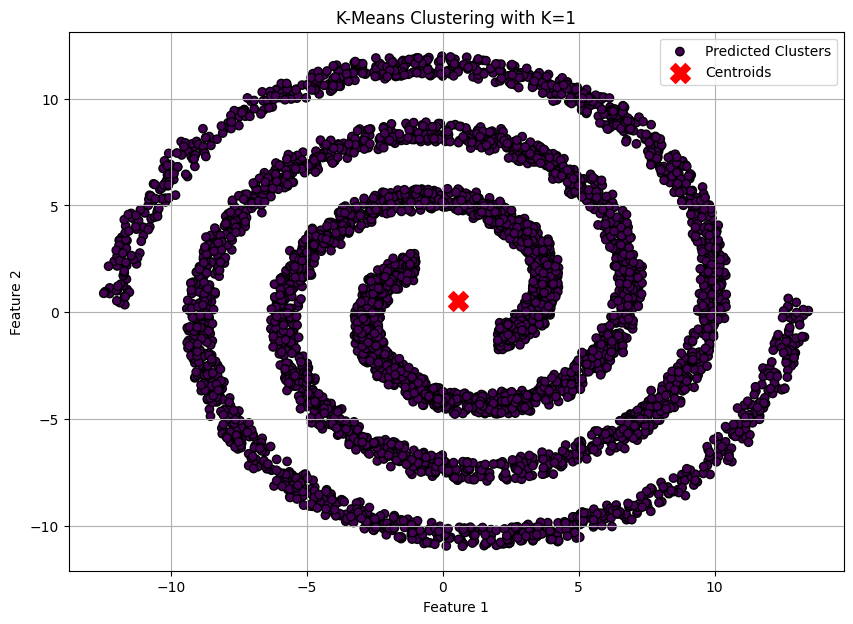

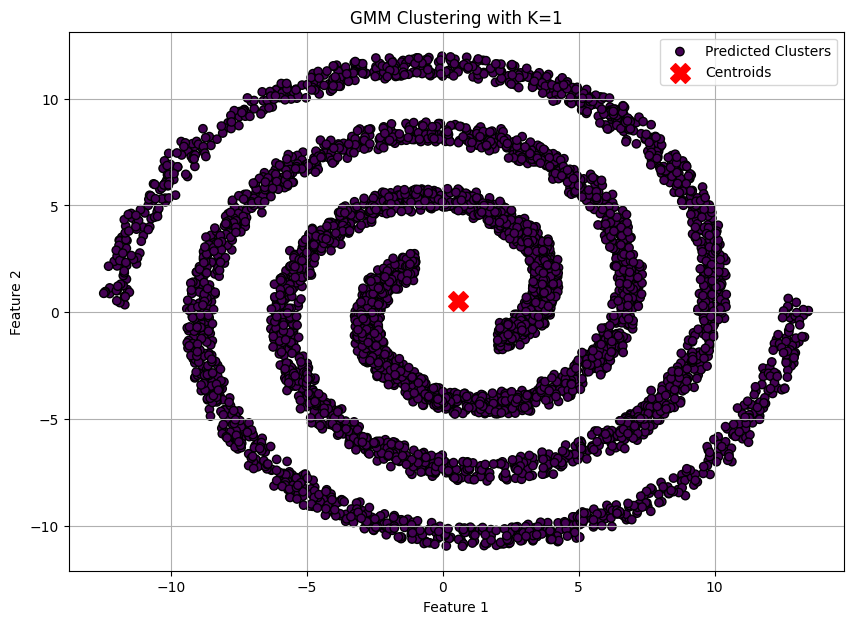

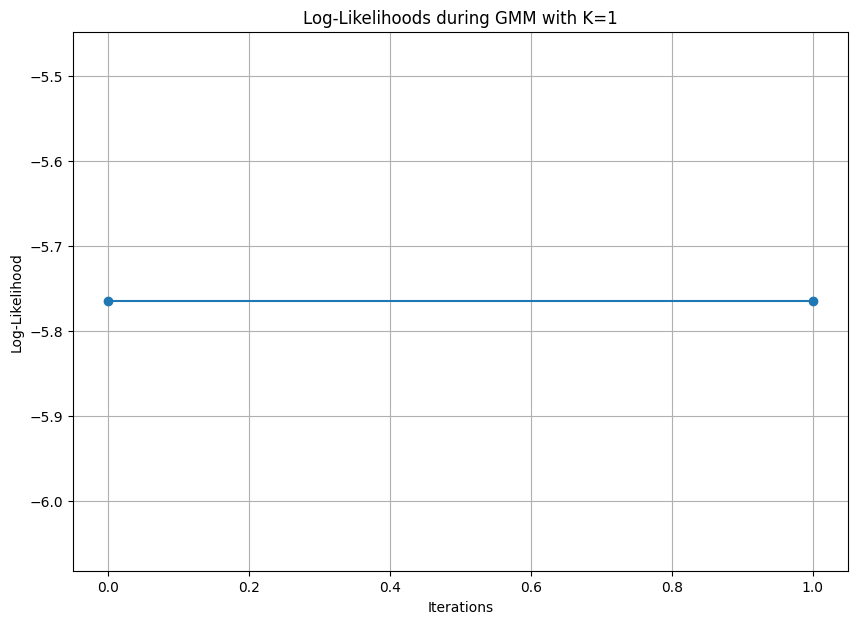


Evaluation for K-Means with K=1:
Confusion Matrix:
[[2447.]
 [2446.]]
Accuracy: 0.5001
Precision: 0.5001
Recall: 1.0002
F1-Score: 0.6668

Evaluation for GMM with K=1:
Confusion Matrix:
[[2447.]
 [2446.]]
Accuracy: 0.5001
Precision: 0.5001
Recall: 1.0002
F1-Score: 0.6668

Running K-Means and GMM for K=2...



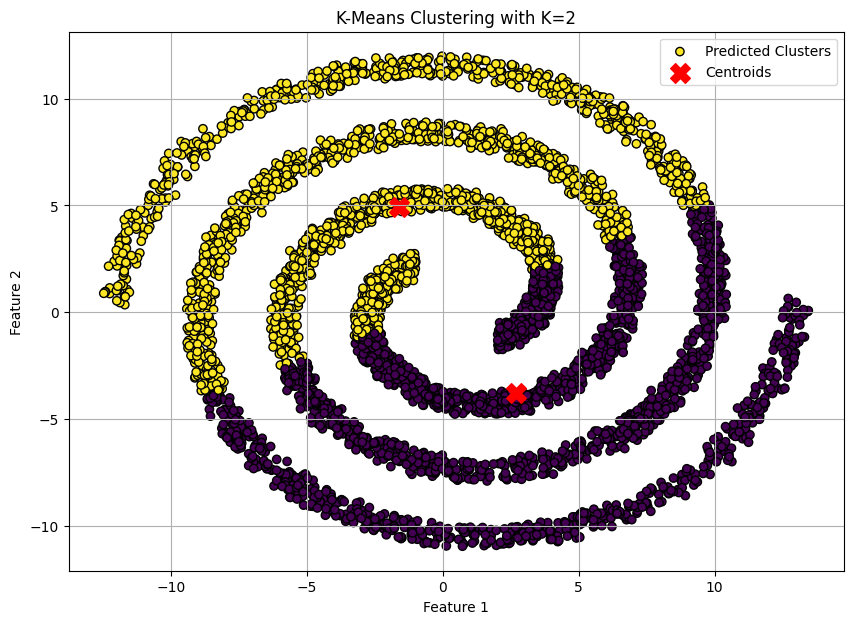

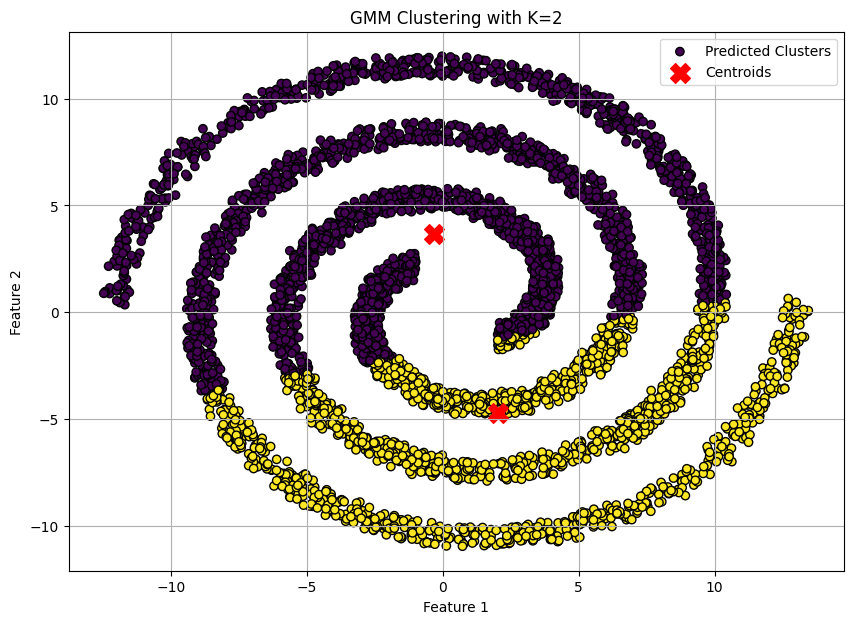

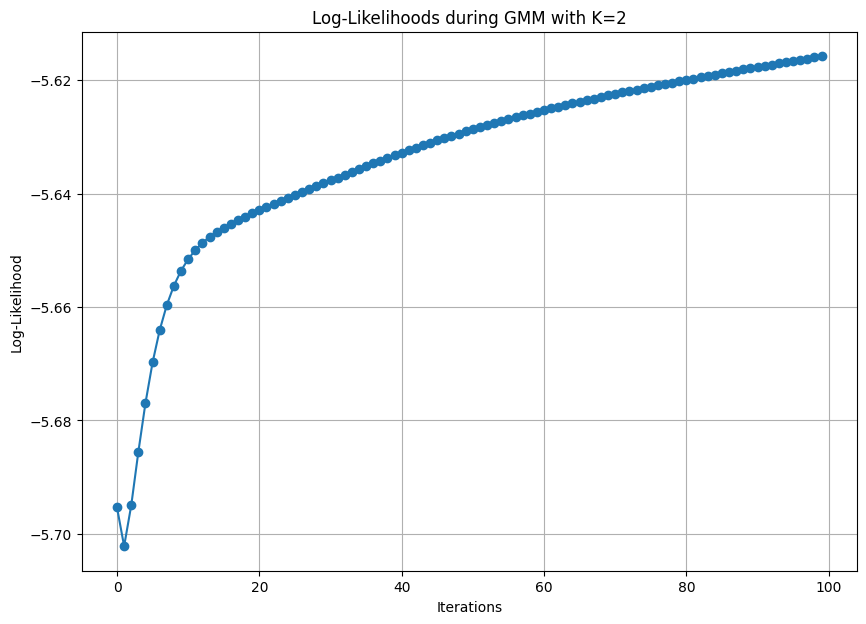


Evaluation for K-Means with K=2:
Confusion Matrix:
[[1392. 1055.]
 [1085. 1361.]]
Accuracy: 0.5626
Precision: 0.5626
Recall: 0.5626
F1-Score: 0.5626

Evaluation for GMM with K=2:
Confusion Matrix:
[[1264. 1183.]
 [1780.  666.]]
Accuracy: 0.3944
Precision: 0.3877
Recall: 0.3944
F1-Score: 0.3853

Running K-Means and GMM for K=4...



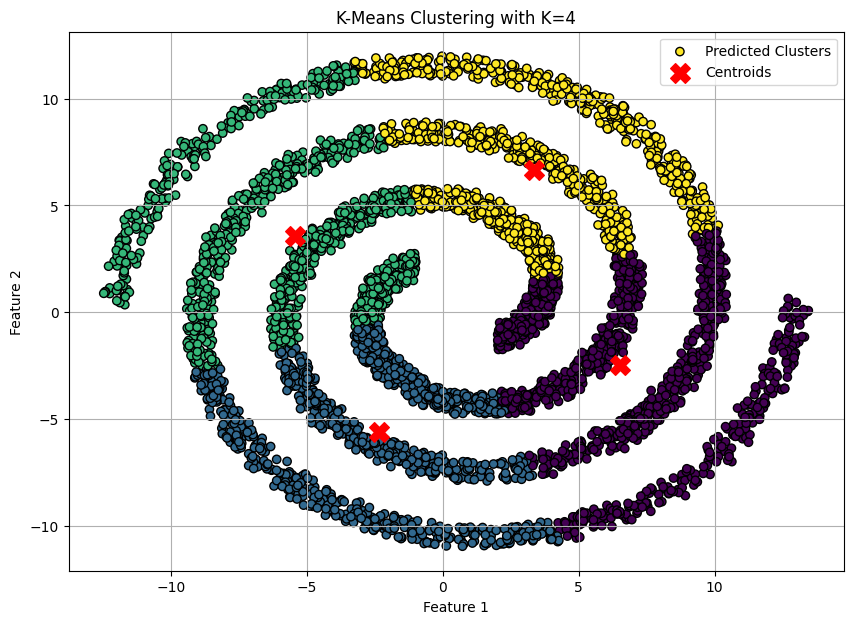

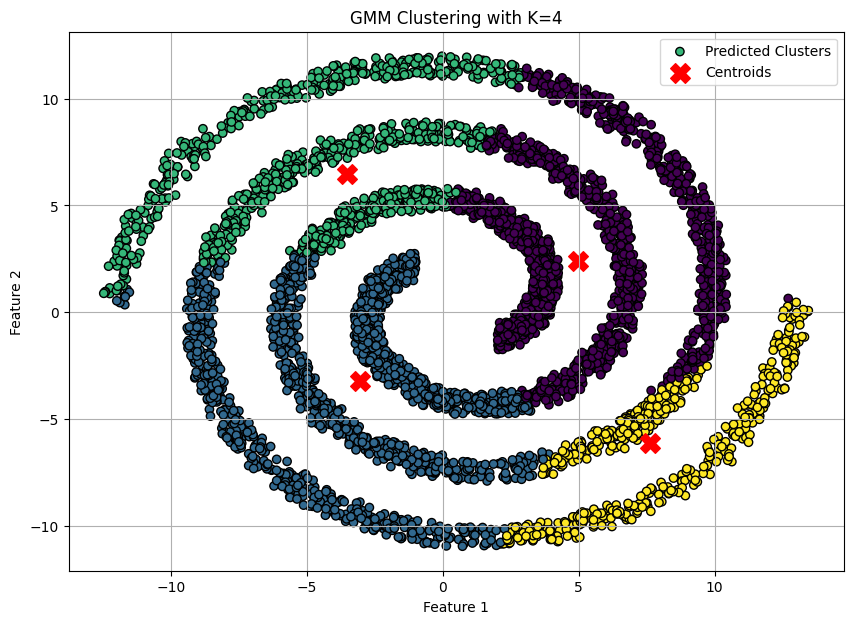

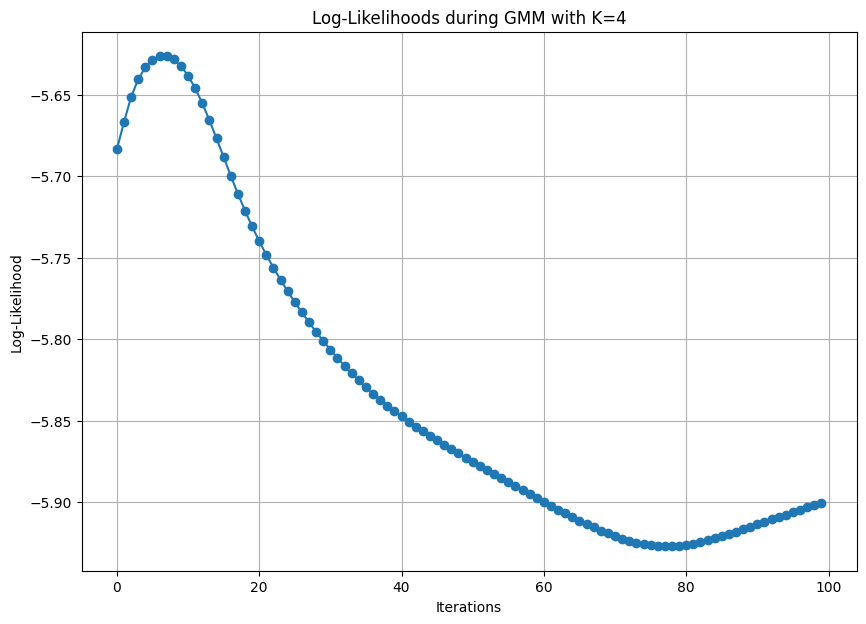


Evaluation for K-Means with K=4:


ValueError: operands could not be broadcast together with shapes (2,) (4,) 

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Function definitions for kmeans, gmm, etc. are assumed to be already implemented

# Load data from the file and split into two classes
with open('NLS_Group03.txt', 'r') as f:
    lines = f.readlines()

# Assuming the first line is a header and skipping it
lines = lines[1:]

# Split data into classes (first 2447 lines belong to Class 1, and the rest to Class 2)
class1_data = []
class2_data = []

for i, line in enumerate(lines):
    if i <= 2446:  # Class 1
        class1_data.append(line.strip().split())
    else:  # Class 2
        class2_data.append(line.strip().split())

# Convert to NumPy arrays for easier manipulation
class1_data = np.array(class1_data, dtype=float)
class2_data = np.array(class2_data, dtype=float)

# Combine data into a single dataset and create labels
data = np.vstack((class1_data, class2_data))
labels = np.array([0]*len(class1_data) + [1]*len(class2_data))

# K values to be used for clustering
K_values = [1, 2, 4, 8, 16, 32, 64]

# Iterate over each K value and run K-Means and GMM
for k in K_values:
    print(f"\nRunning K-Means and GMM for K={k}...\n")
    
    # Run K-Means clustering
    centroids, clusters = kmeans(data, k)
    plot_clusters(data, centroids, clusters, 'K-Means Clustering', k)
    
    # Run GMM clustering
    means, covariances, weights, responsibilities, log_likelihoods = gmm(data, k)
    gmm_clusters = np.argmax(responsibilities, axis=1)
    plot_clusters(data, means, gmm_clusters, 'GMM Clustering', k)
    plot_log_likelihoods(log_likelihoods, 'Log-Likelihoods during GMM', k)

    # Evaluate K-Means clustering
    print(f"\nEvaluation for K-Means with K={k}:")
    evaluate_performance(labels, clusters)

    # Evaluate GMM clustering
    print(f"\nEvaluation for GMM with K={k}:")
    evaluate_performance(labels, gmm_clusters)
